# Suspicious Transaction Detection — Jedha Bootcamp Final Project

**Data Essentials Bootcamp — Jedha**
**Team:** Nashely Castillo, Gwladys Pioche, Robin Pradier

---

## 0. Project context

### The 3 phases of money laundering

1. **Placement** — Introducing illegal funds into the financial system
2. **Layering** — Hiding the origin through complex transactions
3. **Integration** — Returning the funds to the legal economy

### The current context

In 2024, **TRACFIN** (the French anti-money laundering authority) received **215,410 suspicious activity reports**, but only **3,998** were forwarded to the judiciary — that is, **about 98% false positives**.

> **Project question:** *Can we predict whether a transaction is potentially related to money laundering?*

The goal is not to certify that a transaction is suspicious, but to **flag a risk** in order to reduce the workload of human analysts.

### Data source

**SAML-D** dataset (Synthetic Anti-Money Laundering Dataset) — [BOztasUK/Anti_Money_Laundering_Transaction_Data_SAML-D](https://github.com/BOztasUK/Anti_Money_Laundering_Transaction_Data_SAML-D)

- **9,504,852 transactions** in total
- **Working sample: 800,000 rows** (recommended by the trainer, distribution preserved)
- **0.1% suspicious transactions** (833 cases) — extreme imbalance


---

## 1. Imports & data loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    recall_score, precision_score, f1_score, accuracy_score
)

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

In [2]:
# Data loading
# Tries the full 800k dataset first (for local use), otherwise falls back to the 1k sample
import os

CSV_FULL = '../SAML-D_sample_800k.csv'
CSV_SAMPLE = 'data/SAML-D_sample_1k.csv'

if os.path.exists(CSV_FULL):
    csv_path = CSV_FULL
    print(f"Full dataset: {csv_path}")
elif os.path.exists(CSV_SAMPLE):
    csv_path = CSV_SAMPLE
    print(f"Sample: {csv_path}")
    print("Note: using data/SAML-D_sample_1k.csv (1,000 rows). For real results, get the 800k dataset.")
else:
    raise FileNotFoundError("No dataset found. See README to download SAML-D.")

df = pd.read_csv(csv_path)
df.head()


Full dataset: ../SAML-D_sample_800k.csv


,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type
0,18:35:37,2023-02-11,4675905607,6907589690,8145.18,UK pounds,UK pounds,UK,UK,Debit card,0,Normal_Fan_In
1,09:57:50,2023-04-04,1387079033,6476005811,840.83,UK pounds,UK pounds,UK,UK,Debit card,0,Normal_Small_Fan_Out
2,15:58:18,2022-11-15,4203072348,2142717331,186.31,UK pounds,UK pounds,UK,UK,Debit card,0,Normal_Small_Fan_Out
3,03:10:18,2023-04-11,970386825,2627941296,4937.63,UK pounds,UK pounds,UK,UK,Debit card,0,Normal_Fan_In
4,00:17:11,2023-02-03,6094346971,830494049,6502.39,UK pounds,UK pounds,UK,UK,Credit card,0,Normal_Small_Fan_Out


In [3]:
# Basic info about the dataset
df.shape

(800000, 12)

In [4]:
# Summary of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800000 entries, 0 to 799999
Data columns (total 12 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Time                    800000 non-null  object 
 1   Date                    800000 non-null  object 
 2   Sender_account          800000 non-null  int64  
 3   Receiver_account        800000 non-null  int64  
 4   Amount                  800000 non-null  float64
 5   Payment_currency        800000 non-null  object 
 6   Received_currency       800000 non-null  object 
 7   Sender_bank_location    800000 non-null  object 
 8   Receiver_bank_location  800000 non-null  object 
 9   Payment_type            800000 non-null  object 
 10  Is_laundering           800000 non-null  int64  
 11  Laundering_type         800000 non-null  object 
dtypes: float64(1), int64(3), object(8)
memory usage: 73.2+ MB


In [5]:
# Statistical summary of the dataset
df.describe(include='all')

,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type
count,800000,800000,8.000000e+05,8.000000e+05,8.000000e+05,800000,800000,800000,800000,800000,800000.000000,800000
unique,84903,321,NaN,NaN,NaN,13,13,18,18,7,NaN,28
top,11:57:05,2023-02-09,NaN,NaN,NaN,UK pounds,UK pounds,UK,UK,Debit card,NaN,Normal_Small_Fan_Out
freq,31,3158,NaN,NaN,NaN,765768,739491,772914,746219,169603,NaN,292408
mean,NaN,NaN,5.012276e+09,5.007827e+09,8.823698e+03,NaN,NaN,NaN,NaN,NaN,0.001041,NaN
std,NaN,NaN,2.885429e+09,2.885076e+09,2.525987e+04,NaN,NaN,NaN,NaN,NaN,0.032252,NaN
min,NaN,NaN,3.209500e+04,1.326600e+04,5.360000e+00,NaN,NaN,NaN,NaN,NaN,0.000000,NaN
25%,NaN,NaN,2.522946e+09,2.516481e+09,2.149925e+03,NaN,NaN,NaN,NaN,NaN,0.000000,NaN
50%,NaN,NaN,5.007882e+09,5.009650e+09,6.123095e+03,NaN,NaN,NaN,NaN,NaN,0.000000,NaN
75%,NaN,NaN,7.507463e+09,7.503131e+09,1.046361e+04,NaN,NaN,NaN,NaN,NaN,0.000000,NaN


In [6]:
# Check for missing values
df.isnull().any()

Time                      False
Date                      False
Sender_account            False
Receiver_account          False
Amount                    False
Payment_currency          False
Received_currency         False
Sender_bank_location      False
Receiver_bank_location    False
Payment_type              False
Is_laundering             False
Laundering_type           False
dtype: bool

In [7]:
# Distribution of the target variable
print(f"Total transactions : {len(df)}")

# is_laundering: 1 (laundering), 0 (not laundering)
print(" Distribution Is_laundering ") 
for val, count in df['Is_laundering'].value_counts().items():
    print(f"{val} : {count} ({count/len(df)*100:.4f}%)")
   

Total transactions : 800000
 Distribution Is_laundering 
0 : 799167 (99.8959%)
1 : 833 (0.1041%)


---

## 2. Exploratory Data Analysis (EDA)

### 2.1 Class imbalance

The dataset is extremely imbalanced: only **0.1% suspicious transactions**. This imbalance drives every choice that follows — especially the evaluation metric.

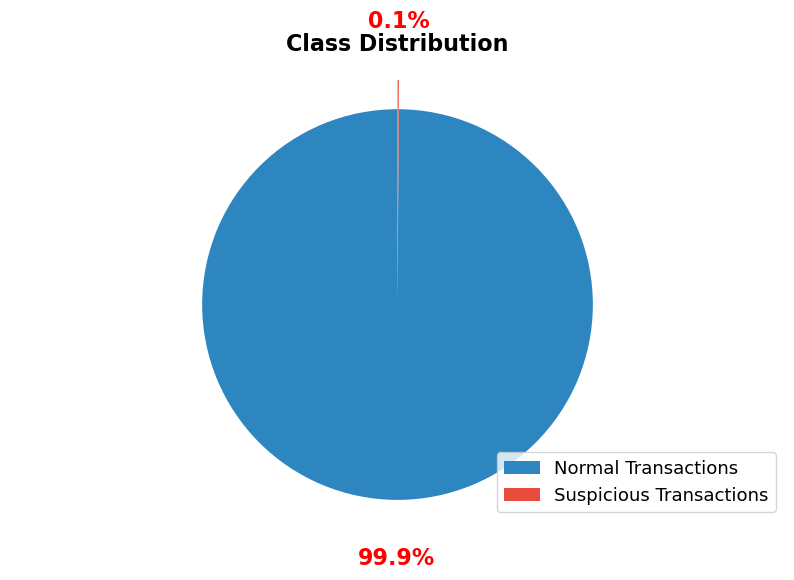

In [8]:
# Visualize the class distribution
class_distribution = df['Is_laundering'].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
wedges, texts, autotexts = ax.pie(
        class_distribution,
        autopct='%1.1f%%',
        colors=['#2E86C1', '#E74C3C'],
        explode=(0, 0.15),
        startangle=90,
        pctdistance=1.3)       # ← pousse le texte plus loin = ligne plus longue

# Rendre la ligne rouge plus épaisse
for text in texts:
    text.set_fontsize(13)

for autotext in autotexts:
    autotext.set_fontsize(16)
    autotext.set_fontweight('bold')
    autotext.set_color('red')  # ← 0.1% en rouge pour le voir mieux

plt.legend(wedges,
           ['Normal Transactions', 'Suspicious Transactions'],
           loc='lower right', fontsize=13)

plt.title('Class Distribution', fontsize=16, fontweight='bold')
plt.axis('equal')
plt.show()

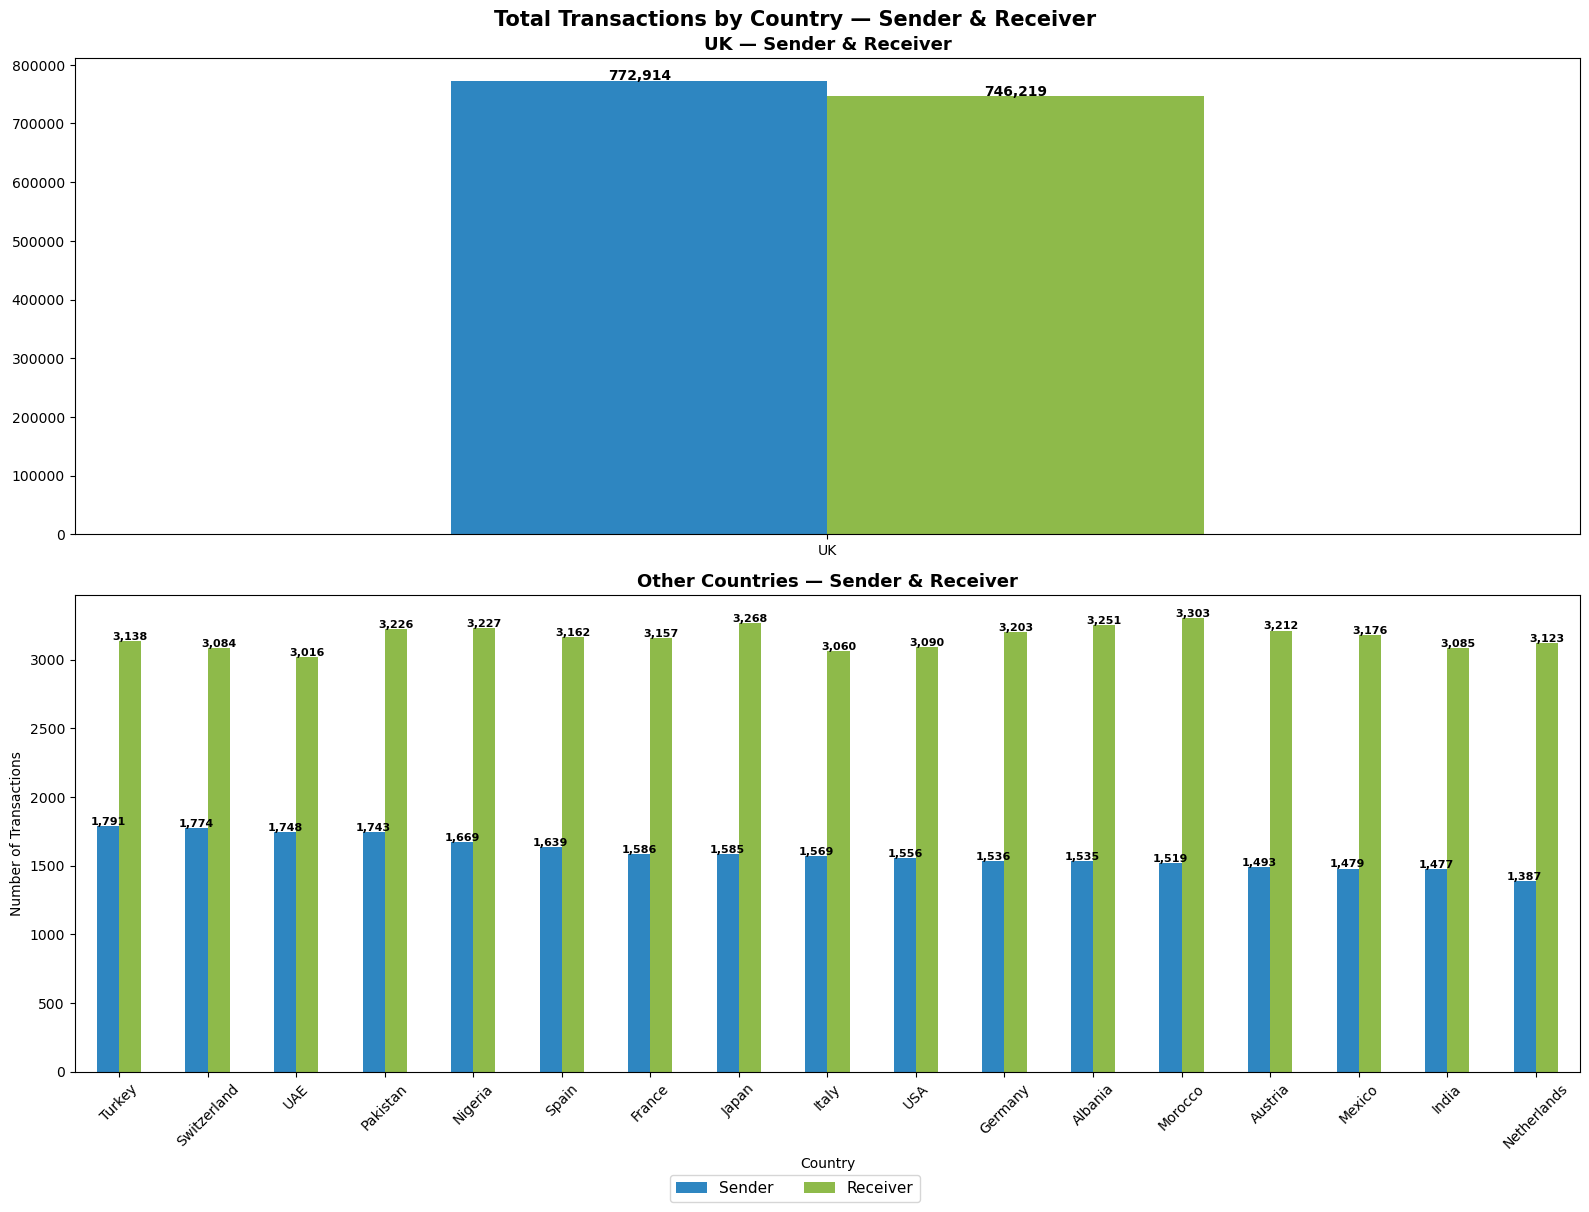

In [9]:
# Visualize the distribution of transactions by country (Sender & Receiver)
def add_bar_labels(ax, offset, fontsize):
    for container in ax.containers:
        for bar in container:
            h = bar.get_height()
            if h > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, h + offset,
                        f'{int(h):,}', ha='center', fontsize=fontsize, fontweight='bold')

pays_df = pd.DataFrame({
    'Sender': df['Sender_bank_location'].value_counts(),
    'Receiver': df['Receiver_bank_location'].value_counts()
}).fillna(0).sort_values('Sender', ascending=False)

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

for ax, data, title, xlabel, xrot, offset, fsize in [
    (axes[0], pays_df.loc[['UK']],  "UK — Sender & Receiver",             "",        0,  1000, 10),
    (axes[1], pays_df.drop('UK'),   "Other Countries — Sender & Receiver", "Country", 45, 10,   8),
]:
    data.plot(kind='bar', ax=ax, color=["#2E86C1", "#8EBA4A"], legend=False)
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.set_xlabel(xlabel)
    ax.tick_params(axis='x', rotation=xrot)
    add_bar_labels(ax, offset, fsize)

axes[1].set_ylabel("Number of Transactions")
fig.legend(['Sender', 'Receiver'], loc='lower center', fontsize=11, ncol=2, bbox_to_anchor=(0.5, -0.02))
plt.suptitle("Total Transactions by Country — Sender & Receiver", fontweight='bold', fontsize=15)
plt.tight_layout()
plt.show()


### 2.2 Countries involved in suspicious transactions

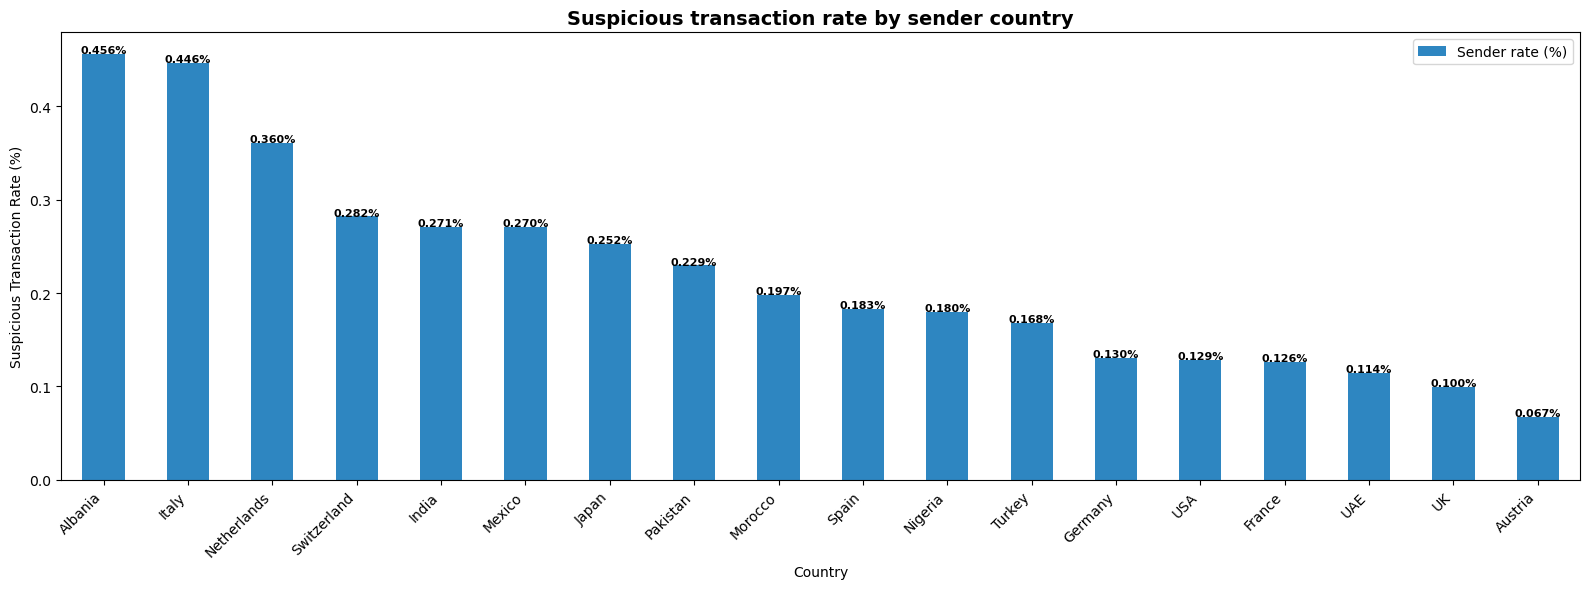

In [10]:
# Suspicious transaction rate by sender country
suspicious = df[df['Is_laundering'] == 1]


sender_suspects = suspicious['Sender_bank_location'].value_counts()
sender_total = df['Sender_bank_location'].value_counts()

#receiver_suspects = suspicious['Receiver_bank_location'].value_counts()
#receiver_total = df['Receiver_bank_location'].value_counts()

# Taux de fraude = transactions suspicious / total transactions par pays
pays_df = pd.DataFrame({
    'sender': sender_suspects / sender_total * 100
    #,'Receiver': receiver_suspects / receiver_total * 100
}).fillna(0)

# Ordre par taux émetteur décroissant
pays_df = pays_df.sort_values('sender', ascending=False)

ax = pays_df.plot(kind='bar', figsize=(16, 6), color=['#2E86C1'])

for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2,
                    height + 0.001,
                    f'{height:.3f}%',
                    ha='center', fontsize=8, fontweight='bold')

plt.title("Suspicious transaction rate by sender country", 
          fontsize=14, fontweight='bold')
plt.xlabel("Country")
plt.ylabel("Suspicious Transaction Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.legend(['Sender rate (%)']) #, 'Receiver rate (%)'
plt.tight_layout()
plt.show()

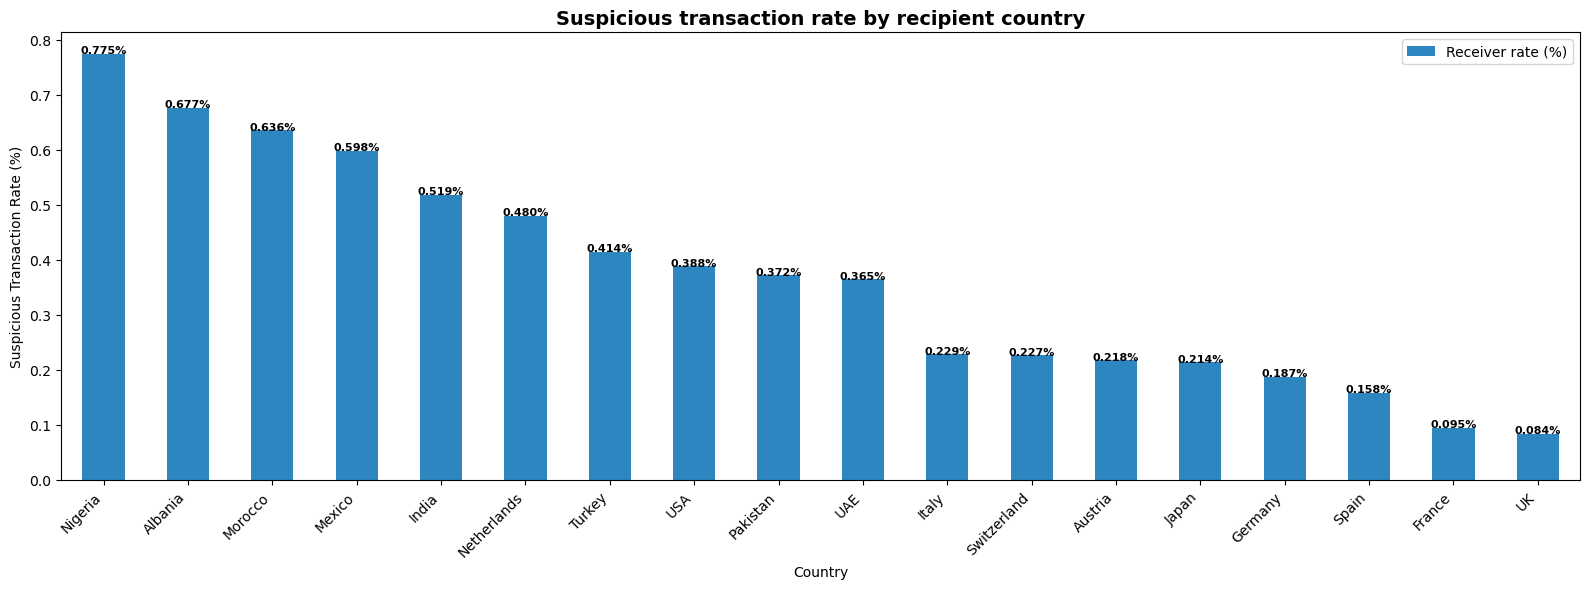

In [11]:
# Suspicious transaction rate by receiver country
suspicious = df[df['Is_laundering'] == 1]


#sender_suspects = suspicious['Sender_bank_location'].value_counts()
#sender_total = df['Sender_bank_location'].value_counts()

receiver_suspects = suspicious['Receiver_bank_location'].value_counts()
receiver_total = df['Receiver_bank_location'].value_counts()

# Taux de fraude = transactions suspicious / total transactions par pays
pays_df = pd.DataFrame({
    #'sender': sender_suspects / sender_total * 100,
    'Receiver': receiver_suspects / receiver_total * 100
}).fillna(0)

# Ordre par taux émetteur décroissant
pays_df = pays_df.sort_values('Receiver', ascending=False)

ax = pays_df.plot(kind='bar', figsize=(16, 6), color=['#2E86C1'])

for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2,
                    height + 0.001,
                    f'{height:.3f}%',
                    ha='center', fontsize=8, fontweight='bold')

plt.title("Suspicious transaction rate by recipient country", 
          fontsize=14, fontweight='bold')
plt.xlabel("Country")
plt.ylabel("Suspicious Transaction Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.legend(['Receiver rate (%)']) #, 'Sender rate (%)'
plt.tight_layout()
plt.show()

**Observations:**
- **Sender side**: Albania, Italy, Netherlands → high suspicious rate (~0.3% to 0.45%)
- **Receiver side**: Nigeria, Saudi Arabia, Morocco, Mexico → highest rates (~0.5% to 0.8%)
- The UK dominates in volume (96.6% of transactions) but acts as a hub

### 2.3 Payment types

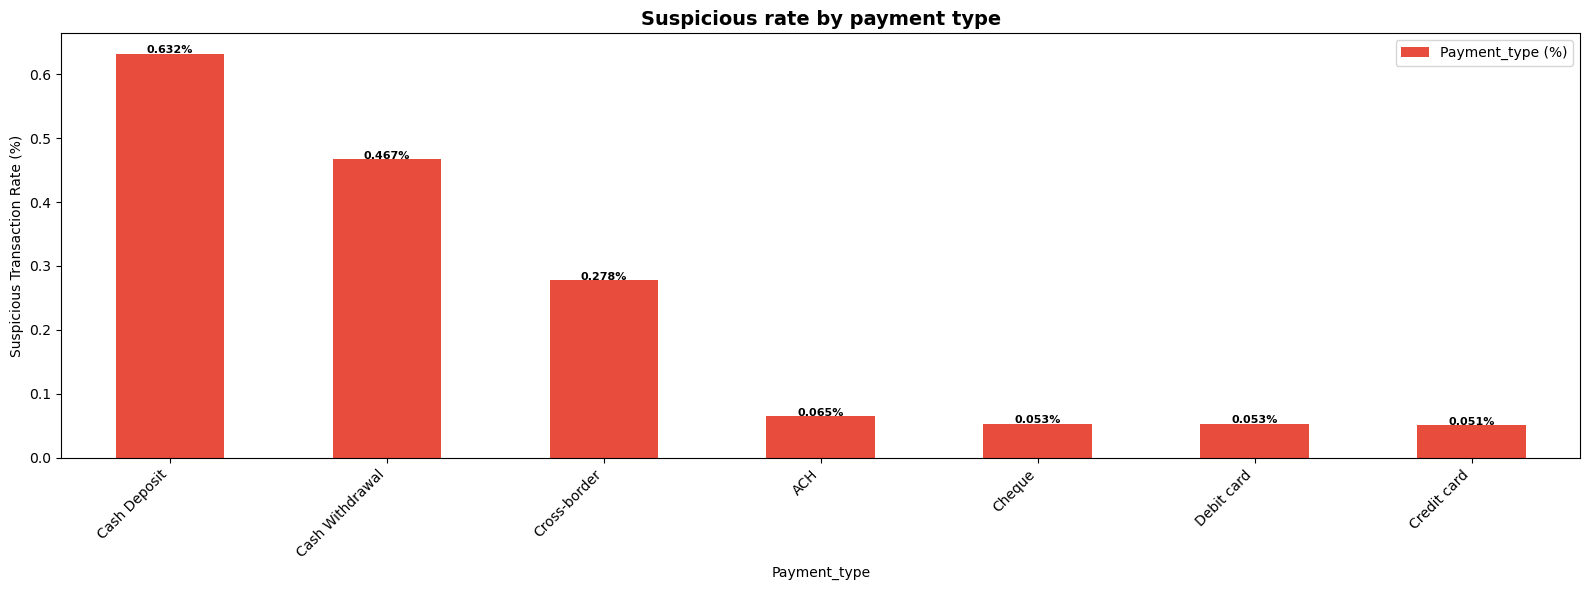

In [12]:
# Percentage of suspicious cases by payment type

suspicious = df[df['Is_laundering'] == 1]

TypePay_suspects = suspicious['Payment_type'].value_counts()
TypePay_total = df['Payment_type'].value_counts()

# Taux de fraude = transactions suspicious / total transactions par pays
typePay_df = pd.DataFrame({
      'Type_payment': TypePay_suspects / TypePay_total * 100
}).fillna(0)

# Ordre par taux émetteur décroissant
typePay_df = typePay_df.sort_values('Type_payment', ascending=False)

ax = typePay_df.plot(kind='bar', figsize=(16, 6), color=['#E74C3C'])

for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2,
                    height + 0.001,
                    f'{height:.3f}%',
                    ha='center', fontsize=8, fontweight='bold')

plt.title("Suspicious rate by payment type", 
          fontsize=14, fontweight='bold')
plt.xlabel("Payment_type")
plt.ylabel("Suspicious Transaction Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.legend(['Payment_type (%)']) #, 'Sender rate (%)'
plt.tight_layout()
plt.show()

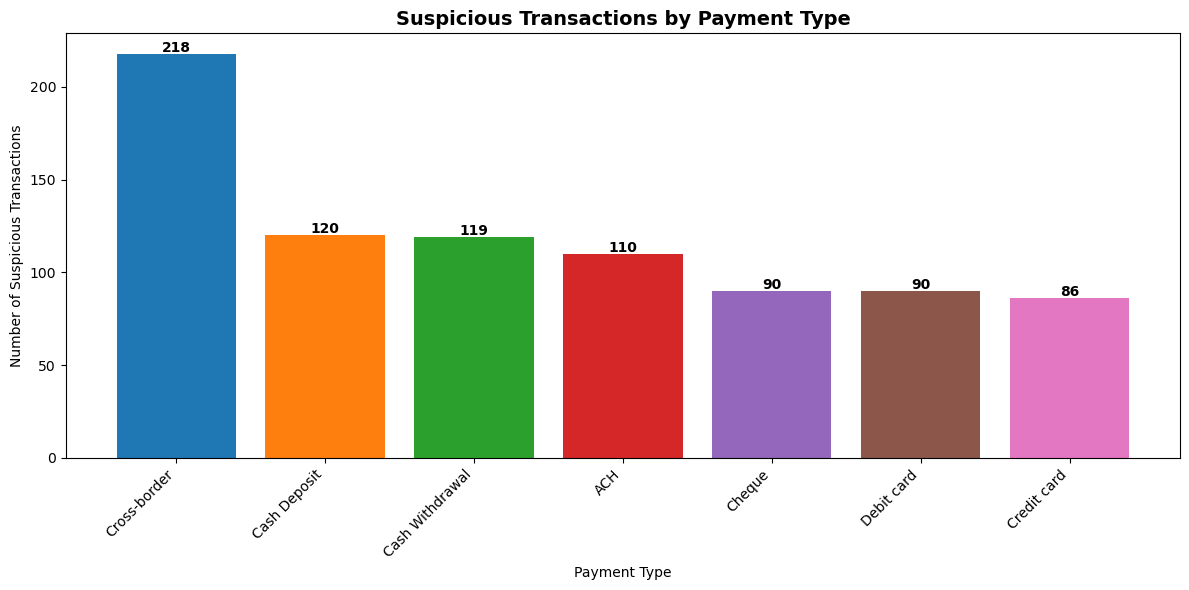

In [13]:
suspicious_payment = df[df['Is_laundering'] == 1]['Payment_type'].value_counts().sort_values(ascending=False)

colors = plt.cm.tab10.colors[:len(suspicious_payment)]

plt.figure(figsize=(12, 6))
bars = plt.bar(suspicious_payment.index, suspicious_payment.values, color=colors)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,             
             str(int(bar.get_height())),       
             ha='center', fontweight='bold')   

plt.xlabel("Payment Type")
plt.ylabel("Number of Suspicious Transactions")
plt.title("Suspicious Transactions by Payment Type", 
          fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Observations:**
**Cash transactions** (cash deposit, cash withdrawal) show the highest suspicion rates. Electronic payments are the least risky.

### 2.4 Money laundering typologies

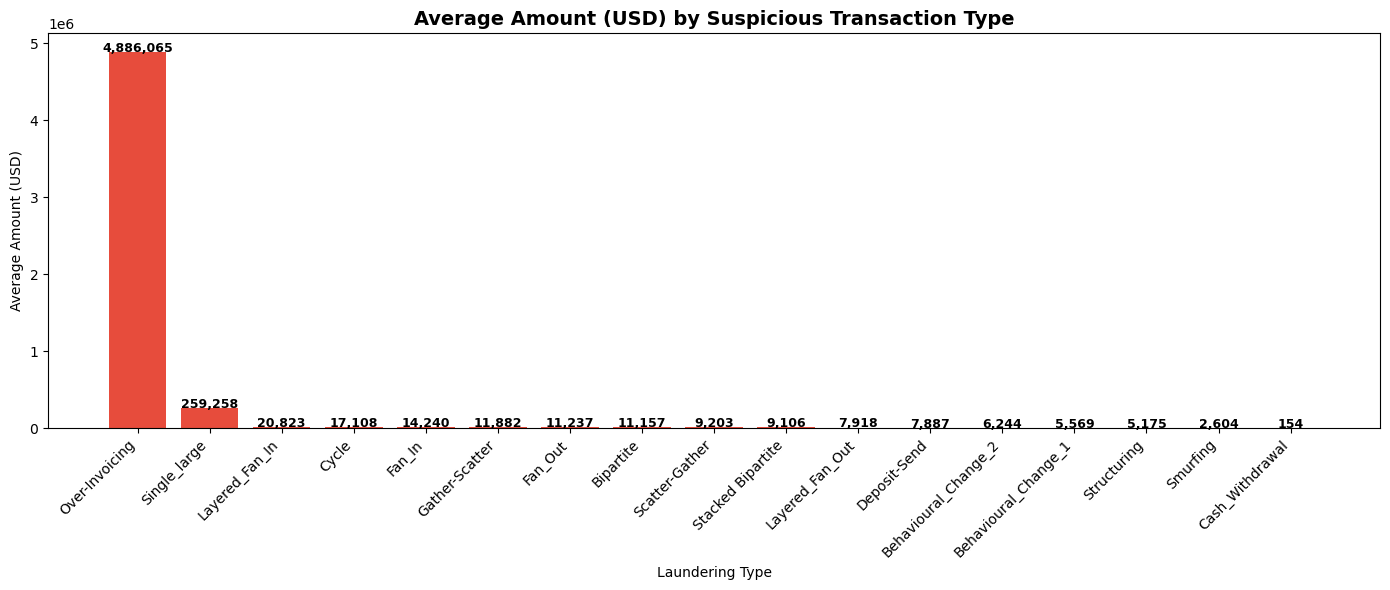

In [14]:
# Average amount of suspicious transactions by laundering type
suspicious = df[df['Is_laundering'] == 1]

amount_by_type = suspicious.groupby('Laundering_type')['Amount'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
bars = plt.bar(amount_by_type.index, amount_by_type.values, color='#E74C3C')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 100,
             f'{bar.get_height():,.0f}',
             ha='center', fontweight='bold', fontsize=9)

plt.title("Average Amount (USD) by Suspicious Transaction Type",
          fontweight='bold', fontsize=14)
plt.xlabel("Laundering Type")
plt.ylabel("Average Amount (USD)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Money laundering typology descriptions

- **Over-Invoicing**: artificially inflating an invoice price to legally transfer large sums of money between two companies.
- **Single_Large**: a single very large transaction to move funds quickly.
- **Structuring**: deliberately splitting transactions to avoid reporting thresholds.
- **Smurfing**: small repeated deposits by multiple people to avoid detection.
- **Cash_Withdrawal**: cash withdrawals to make funds untraceable.

### 2.5 Suspicious accounts

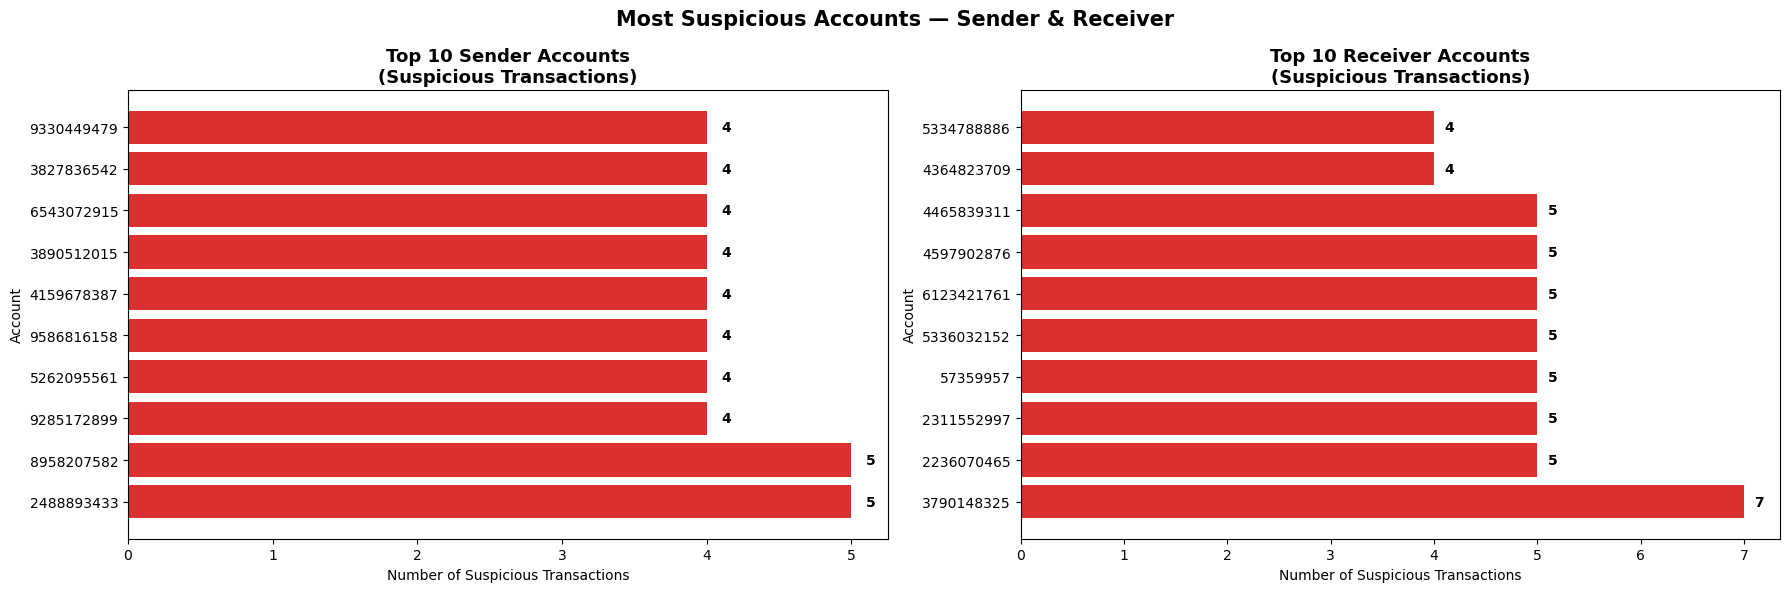


=== Typologies des Top 10 Sender Accounts ===
   Sender_account  Laundering_type  Count
0      2488893433         Smurfing      5
1      3827836542  Cash_Withdrawal      4
2      3890512015  Cash_Withdrawal      4
3      4159678387  Cash_Withdrawal      4
4      5262095561         Smurfing      4
5      6543072915         Smurfing      4
6      8958207582  Cash_Withdrawal      5
7      9285172899  Cash_Withdrawal      4
8      9330449479  Cash_Withdrawal      4
9      9586816158  Cash_Withdrawal      4

=== Typologies des Top 10 Receiver Accounts ===
   Receiver_account  Laundering_type  Count
0          57359957         Smurfing      5
1        2236070465      Structuring      5
2        2311552997      Structuring      5
3        3790148325      Structuring      7
4        4364823709         Smurfing      4
5        4465839311  Cash_Withdrawal      5
6        4597902876      Structuring      5
7        5334788886         Smurfing      4
8        5336032152      Structuring      5
9 

In [15]:
# Analyze the most suspicious accounts (top senders & receivers)
laundering_df = df[df['Is_laundering'] == 1]

# Top 10 most suspicious sender accounts
top_senders = laundering_df.groupby('Sender_account').size().sort_values(ascending=False).head(10)

# Top 10 most suspicious accounts destinataires les plus suspects  
top_receivers = laundering_df.groupby('Receiver_account').size().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Graphique 1 - Top senders
bars1 = axes[0].barh(top_senders.index.astype(str), top_senders.values, color="#D93030")
axes[0].set_title("Top 10 Sender Accounts\n(Suspicious Transactions)", 
                   fontweight='bold', fontsize=13)
axes[0].set_xlabel("Number of Suspicious Transactions")
axes[0].set_ylabel("Account")
for bar in bars1:
    axes[0].text(bar.get_width() + 0.1,
                 bar.get_y() + bar.get_height()/2,
                 str(int(bar.get_width())),
                 va='center', fontweight='bold')

# Graphique 2 - Top receivers
bars2 = axes[1].barh(top_receivers.index.astype(str), top_receivers.values, color="#D93030")
axes[1].set_title("Top 10 Receiver Accounts\n(Suspicious Transactions)", 
                   fontweight='bold', fontsize=13)
axes[1].set_xlabel("Number of Suspicious Transactions")
axes[1].set_ylabel("Account")
for bar in bars2:
    axes[1].text(bar.get_width() + 0.1,
                 bar.get_y() + bar.get_height()/2,
                 str(int(bar.get_width())),
                 va='center', fontweight='bold')

plt.suptitle("Most Suspicious Accounts — Sender & Receiver",
             fontweight='bold', fontsize=15)
plt.tight_layout()
plt.show()

# Typologies utilisées par les top comptes
print("\n=== Typologies des Top 10 Sender Accounts ===")
top_sender_typologies = laundering_df[laundering_df['Sender_account'].isin(top_senders.index)]
print(top_sender_typologies.groupby(['Sender_account', 'Laundering_type']).size().reset_index(name='Count'))

print("\n=== Typologies des Top 10 Receiver Accounts ===")
top_receiver_typologies = laundering_df[laundering_df['Receiver_account'].isin(top_receivers.index)]
print(top_receiver_typologies.groupby(['Receiver_account', 'Laundering_type']).size().reset_index(name='Count'))

---

## 3. Preprocessing

| Step | Detail |
|---|---|
| **Missing values** | None (synthetic dataset) |
| **Categorical encoding** | `LabelEncoder` on `Payment_type`, currencies, countries |
| **Feature engineering** | `sender_tx_count`, `receiver_tx_count` |
| **Train/Test split** | 80 / 20 with `stratify=y` (preserves the 0.1% suspicious in each set) |
| **Normalization** | `StandardScaler` (z-score) on numerical features |
| **Imbalance** | `class_weight='balanced'` — higher weight on the minority class |
| **Reproducibility** | `random_state=42` |

In [16]:
# 1. Make a copy of the dataset
df_ml = df.copy()

# 2. Créer les nouvelles colonnes de comptage
df_ml['sender_tx_count'] = df_ml.groupby('Sender_account')['Sender_account'].transform('count')
df_ml['receiver_tx_count'] = df_ml.groupby('Receiver_account')['Receiver_account'].transform('count')

# 4. Vérification
print(df_ml.shape)
print(df_ml.columns.tolist())
print(df_ml.head(5))

(800000, 14)
['Time', 'Date', 'Sender_account', 'Receiver_account', 'Amount', 'Payment_currency', 'Received_currency', 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type', 'Is_laundering', 'Laundering_type', 'sender_tx_count', 'receiver_tx_count']
       Time        Date  Sender_account  Receiver_account   Amount  \
0  18:35:37  2023-02-11      4675905607        6907589690  8145.18   
1  09:57:50  2023-04-04      1387079033        6476005811   840.83   
2  15:58:18  2022-11-15      4203072348        2142717331   186.31   
3  03:10:18  2023-04-11       970386825        2627941296  4937.63   
4  00:17:11  2023-02-03      6094346971         830494049  6502.39   

  Payment_currency Received_currency Sender_bank_location  \
0        UK pounds         UK pounds                   UK   
1        UK pounds         UK pounds                   UK   
2        UK pounds         UK pounds                   UK   
3        UK pounds         UK pounds                   UK   
4        UK p

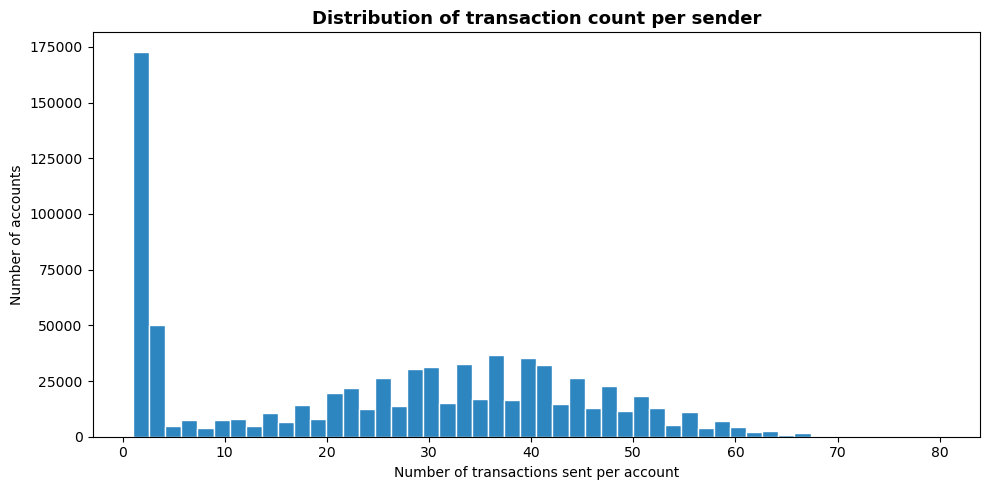

In [17]:
# Visualize the distribution of transaction count per sender
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(df_ml['sender_tx_count'], bins=50, color='#2E86C1', edgecolor='white')

plt.title("Distribution of transaction count per sender", fontsize=13, fontweight='bold')
plt.xlabel("Number of transactions sent per account")
plt.ylabel("Number of accounts")

plt.tight_layout()
plt.show()

---

## 4. Modeling

Five models tested progressively, from simplest to most advanced:

| # | Model | Configuration |
|---|---|---|
| M1 | Logistic Regression | `X = Amount` only |
| M2 | Logistic Regression | + `class_weight='balanced'` |
| M3 | Logistic Regression | + 6 features |
| M4 | Decision Tree | `max_depth=10`, `class_weight='balanced'` |
| M5 | Random Forest | 100 trees, `max_depth=15` |

### Model 1 — Logistic Regression (Amount only)

**Initial hypothesis:** is the transaction amount alone enough to predict suspiciousness?

In [18]:
from sklearn.linear_model import LogisticRegression # the logistic regression algorithm.
from sklearn.model_selection import train_test_split # the function that splits data into train and test.
from sklearn.preprocessing import StandardScaler # les outils de preprocessing — StandardScaler pour normaliser les chiffres
from sklearn.metrics import classification_report, confusion_matrix # les outils pour évaluer le modèle.

# Séparer X et y
print("Splitting dataset into X and y...") 
X = df[['Amount']] # X contient les features — les informations qu'on donne au modèle pour qu'il apprenne.
y = df['Is_laundering'] # y contient la target — ce qu'on veut prédire (0 ou 1).
print("...Done.")

# Séparer train et test
print("Splitting into train and test...") # 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
 # 80% pour entraîner, 20% pour tester, random_state=42 pour un résultat reproductible, stratify=y conserve les mêmes proportions 0.1% suspicious dans train et test
print("...Done.")

# Standardiser
print("Standardizing...")
scaler = StandardScaler() 
X_train = scaler.fit_transform(X_train) # apprend la moyenne et l'écart-type puis applique la transformation sur X_train
X_test = scaler.transform(X_test) # applique la même transformation sur X_test (sans réapprendre la moyenne et l'écart-type)
print("...Done.")

# Entraîner le modèle
print("Training model...")
classifier = LogisticRegression(random_state=42,)  # random_state=42 pour un résultat reproductible.
classifier.fit(X_train, y_train)
print("...Done.")

# Évaluer le modèle
y_pred = classifier.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Splitting dataset into X and y...
...Done.
Splitting into train and test...


...Done.
Standardizing...
...Done.
Training model...


...Done.
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    159833
           1       0.00      0.00      0.00       167

    accuracy                           1.00    160000
   macro avg       0.50      0.50      0.50    160000
weighted avg       1.00      1.00      1.00    160000

[[159833      0]
 [   167      0]]


**Result: Recall = 0%.** Amount alone does not discriminate — many normal transactions have high amounts and many suspicious ones have small amounts (smurfing, structuring).

### Model 2 — Logistic Regression + class_weight balanced

In [19]:
from sklearn.linear_model import LogisticRegression # the logistic regression algorithm.
from sklearn.model_selection import train_test_split # the function that splits data into train and test.
from sklearn.preprocessing import StandardScaler # les outils de preprocessing — StandardScaler pour normaliser les chiffres
from sklearn.metrics import classification_report, confusion_matrix # les outils pour évaluer le modèle.

# Séparer X et y
print("Splitting dataset into X and y...") 
X = df[['Amount']] # X contient les features — les informations qu'on donne au modèle pour qu'il apprenne.
y = df['Is_laundering'] # y contient la target — ce qu'on veut prédire (0 ou 1).
print("...Done.")

# Séparer train et test
print("Splitting into train and test...") # 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
 # 80% pour entraîner, 20% pour tester, random_state=42 pour un résultat reproductible, stratify=y conserve les mêmes proportions 0.1% suspicious dans train et test
print("...Done.")

# Standardiser
print("Standardizing...")
scaler = StandardScaler() 
X_train = scaler.fit_transform(X_train) # apprend la moyenne et l'écart-type puis applique la transformation sur X_train
X_test = scaler.transform(X_test) # applique la même transformation sur X_test (sans réapprendre la moyenne et l'écart-type)
print("...Done.")

# Entraîner le modèle
print("Training model...")
classifier = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)  # random_state=42 pour un résultat reproductible et class_weight='balanced' pour compenser le déséquilibre des classes, max_iter=1000 pour s'assurer que l'algorithme converge même avec les données déséquilibrées.
classifier.fit(X_train, y_train)
print("...Done.")

# Évaluer le modèle
y_pred = classifier.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Splitting dataset into X and y...
...Done.
Splitting into train and test...


...Done.
Standardizing...
...Done.
Training model...


...Done.
              precision    recall  f1-score   support

           0       1.00      0.80      0.89    159833
           1       0.00      0.22      0.00       167

    accuracy                           0.80    160000
   macro avg       0.50      0.51      0.45    160000
weighted avg       1.00      0.80      0.89    160000

[[128107  31726]
 [   131     36]]


**Result: Recall ~22%.** Adding `class_weight='balanced'` forces the model to pay attention to the minority class, but predictive power is still limited with a single feature.

### Model 3 — Logistic Regression + 6 features

In [20]:

## importing machine learning libraries

from sklearn.linear_model import LogisticRegression  # l'algorithme de régression logistique.
from sklearn.model_selection import train_test_split # la fonction qui sépare les données en train et test.
from sklearn.preprocessing import StandardScaler, LabelEncoder # les outils de preprocessing — StandardScaler pour normaliser les chiffres, LabelEncoder pour convertir le texte en chiffres.
from sklearn.metrics import classification_report, confusion_matrix # les outils pour évaluer le modèle.

# Encoder les colonnes texte
df_encoded = df.copy() # On crée une copie du dataset pour ne pas modifier l'original.
for col in ['Payment_type', 'Payment_currency', 'Received_currency',
            'Sender_bank_location', 'Receiver_bank_location']:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

# Séparer X et y
print("Splitting dataset into X and y...")
X = df_encoded[['Amount', 'Payment_type', 'Payment_currency', 
                'Received_currency', 'Sender_bank_location', 
                'Receiver_bank_location']] # X contient les features — les informations qu'on donne au modèle pour qu'il apprenne.
y = df_encoded['Is_laundering'] # y contient la target — ce qu'on veut prédire (0 ou 1).
print("...Done.")

# Train/test split
print("Splitting into train and test...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, # 80% pour entraîner, 20% pour tester
                                                      random_state=42, #  résultat reproductible — tout le monde obtient la même séparation
                                                      stratify=y) # stratify=y pour garder la même proportion de classes dans train et test ( conserve les mêmes proportions 0.1% suspicious dans train et test)
print("...Done.")

# Standardiser
print("Standardizing...")
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # apprend la moyenne et l'écart-type puis applique la transformation sur X_train
X_test = scaler.transform(X_test) # applique la même transformation sur X_test (sans réapprendre la moyenne et l'écart-type)
print("...Done.")

# Entraîner le modèle
print("Training model...") # random_state=42 pour un résultat reproductible, class_weight='balanced' pour compenser le déséquilibre des classes, max_iter=1000 pour s'assurer que l'algorithme converge même avec les données déséquilibrées.
classifier = LogisticRegression(random_state=42, 
                                class_weight='balanced', 
                                max_iter=1000)
classifier.fit(X_train, y_train) # entraîne le modèle sur les données d'entraînement
print("...Done.")

# Évaluer
y_pred = classifier.predict(X_test) # prédit les classes sur les données de test
print(classification_report(y_test, y_pred))# affiche les métriques de classification (précision, rappel, f1-score) pour chaque classe
print(confusion_matrix(y_test, y_pred))# affiche la matrice de confusion pour voir les vrais positifs, faux positifs, vrais négatifs et faux négatifs.

Splitting dataset into X and y...
...Done.
Splitting into train and test...


...Done.
Standardizing...
...Done.
Training model...


...Done.
              precision    recall  f1-score   support

           0       1.00      0.70      0.82    159833
           1       0.00      0.38      0.00       167

    accuracy                           0.70    160000
   macro avg       0.50      0.54      0.41    160000
weighted avg       1.00      0.70      0.82    160000

[[111858  47975]
 [   103     64]]


**Result: Recall ~38%.** Significantly better. Logistic regression remains linear and plateaus here.

### Model 4 — Decision Tree (max_depth=10) ⭐ SELECTED MODEL

A decision tree asks a sequence of yes/no questions on the features to reach a prediction. Limiting `max_depth=10` prevents overfitting.

In [21]:
# ============================================================
# Model 4: Decision Tree (Decision Tree)
# ============================================================
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score, precision_score

# 1. Encoder les colonnes texte (les arbres n''ont PAS besoin de StandardScaler)
df_tree = df.copy()
for col in ['Payment_type', 'Payment_currency', 'Received_currency',
            'Sender_bank_location', 'Receiver_bank_location']:
    df_tree[col] = LabelEncoder().fit_transform(df_tree[col])

# 2. Features et target
X = df_tree[['Amount', 'Payment_type', 'Payment_currency',
             'Received_currency', 'Sender_bank_location',
             'Receiver_bank_location']]
y = df_tree['Is_laundering']

# 3. Split train/test stratifie (garde la proportion 0.1% dans chaque set)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Entrainement
# - max_depth=10 : on limite la profondeur pour eviter le sur-apprentissage
# - class_weight=''balanced'' : compense le desequilibre 99.9% / 0.1%
# - random_state=42 : resultat reproductible
tree = DecisionTreeClassifier(
    max_depth=10,
    class_weight='balanced',
    random_state=42
)
tree.fit(X_train, y_train)

# 5. Predictions
y_train_pred = tree.predict(X_train)
y_test_pred  = tree.predict(X_test)

# 6. Evaluation
print("=== Rapport sur le TEST ===")
print(classification_report(y_test, y_test_pred, zero_division=0))
print("Matrice de confusion (test) :")
print(confusion_matrix(y_test, y_test_pred))

print("\n=== Comparaison TRAIN vs TEST (detection de sur-apprentissage) ===")
print(f"Recall    train={recall_score(y_train, y_train_pred):.3f}  | test={recall_score(y_test, y_test_pred):.3f}")
print(f"Precision train={precision_score(y_train, y_train_pred, zero_division=0):.3f}  | test={precision_score(y_test, y_test_pred, zero_division=0):.3f}")
print(f"F1        train={f1_score(y_train, y_train_pred):.3f}  | test={f1_score(y_test, y_test_pred):.3f}")

# 7. Importance des features (ce que l''arbre a trouve utile)
import pandas as pd
importance = pd.Series(tree.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\n=== Importance des features ===")
print(importance)

# Save DT-specific variables for later visualization (avoid overwrite by RF)
dt_y_train_pred = y_train_pred
dt_y_test_pred = y_test_pred
dt_importance = importance.copy()


=== Rapport sur le TEST ===
              precision    recall  f1-score   support

           0       1.00      0.88      0.94    159833
           1       0.00      0.43      0.01       167

    accuracy                           0.88    160000
   macro avg       0.50      0.65      0.47    160000
weighted avg       1.00      0.88      0.94    160000

Matrice de confusion (test) :
[[140864  18969]
 [    96     71]]

=== Comparaison TRAIN vs TEST (detection de sur-apprentissage) ===
Recall    train=0.707  | test=0.425
Precision train=0.006  | test=0.004


F1        train=0.012  | test=0.007

=== Importance des features ===
Amount                    0.424587
Payment_type              0.266485
Received_currency         0.202973
Payment_currency          0.071517
Receiver_bank_location    0.025118
Sender_bank_location      0.009320
dtype: float64


### Model 5 — Random Forest (100 trees, max_depth=15)

A Random Forest trains 100 trees on random samples of the data and aggregates their votes.

In [22]:
# ============================================================
# Model 5: Random Forest (Random Forest)
# ============================================================
# Une foret = plusieurs arbres entraines sur des echantillons differents.
# Chaque arbre vote, la foret prend la majorite. Plus robuste qu''un seul arbre.
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score, precision_score

# On reutilise X_train, X_test, y_train, y_test du modele 4 (meme preparation)

forest = RandomForestClassifier(
    n_estimators=100,         # nombre d''arbres dans la foret
    max_depth=15,             # profondeur max de chaque arbre
    class_weight='balanced',  # compense le desequilibre des classes
    n_jobs=-1,                # utilise tous les coeurs du CPU
    random_state=42
)
forest.fit(X_train, y_train)

y_train_pred = forest.predict(X_train)
y_test_pred  = forest.predict(X_test)

print("=== Rapport sur le TEST ===")
print(classification_report(y_test, y_test_pred, zero_division=0))
print("Matrice de confusion (test) :")
print(confusion_matrix(y_test, y_test_pred))

print("\n=== Comparaison TRAIN vs TEST ===")
print(f"Recall    train={recall_score(y_train, y_train_pred):.3f}  | test={recall_score(y_test, y_test_pred):.3f}")
print(f"Precision train={precision_score(y_train, y_train_pred, zero_division=0):.3f}  | test={precision_score(y_test, y_test_pred, zero_division=0):.3f}")
print(f"F1        train={f1_score(y_train, y_train_pred):.3f}  | test={f1_score(y_test, y_test_pred):.3f}")

# Importance des features selon la foret
importance = pd.Series(forest.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\n=== Importance des features (Random Forest) ===")
print(importance)

=== Rapport sur le TEST ===
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    159833
           1       0.01      0.13      0.01       167

    accuracy                           0.98    160000
   macro avg       0.50      0.56      0.50    160000
weighted avg       1.00      0.98      0.99    160000

Matrice de confusion (test) :
[[156673   3160]
 [   145     22]]

=== Comparaison TRAIN vs TEST ===
Recall    train=0.712  | test=0.132
Precision train=0.037  | test=0.007


F1        train=0.070  | test=0.013

=== Importance des features (Random Forest) ===
Amount                    0.532583
Payment_type              0.209994
Received_currency         0.118534
Receiver_bank_location    0.071977
Payment_currency          0.044448
Sender_bank_location      0.022463
dtype: float64


---

## 5. Evaluation of the selected model (Decision Tree, max_depth=10)

On the test set, the model achieves a **recall of ~43%** — it detects nearly half of the suspicious transactions, with mild overfitting (train recall ~70%).

### Visualization of selected model results

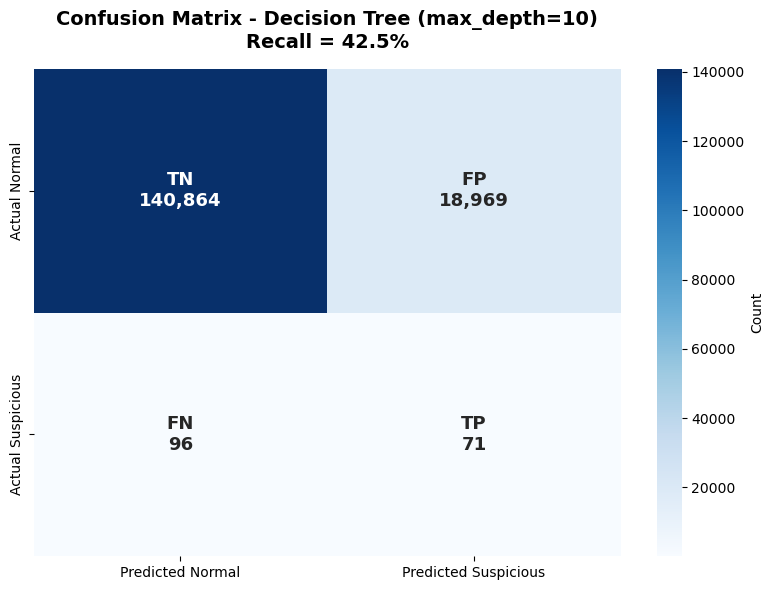

In [23]:
# Visualisation : matrice de confusion + importance des features
import seaborn as sns
import numpy as np

# 1. Matrice de confusion (heatmap)
cm = confusion_matrix(y_test, dt_y_test_pred)
tn, fp, fn, tp = cm.ravel()
recall_val = tp / (tp + fn) if (tp + fn) > 0 else 0

annot = np.array([
    [f"TN\n{tn:,}", f"FP\n{fp:,}"],
    [f"FN\n{fn:,}", f"TP\n{tp:,}"],
])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=annot, fmt="", cmap="Blues",
    xticklabels=["Predicted Normal", "Predicted Suspicious"],
    yticklabels=["Actual Normal", "Actual Suspicious"],
    annot_kws={"fontsize": 13, "fontweight": "bold"},
    cbar_kws={"label": "Count"}, ax=ax,
)
ax.set_title(f"Confusion Matrix - Decision Tree (max_depth=10)\nRecall = {recall_val*100:.1f}%",
             fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()


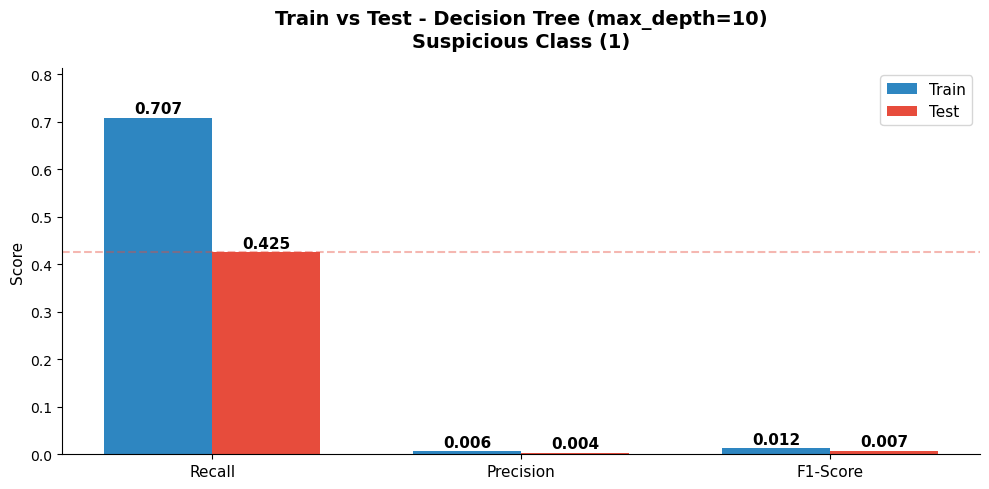

In [24]:
# Train vs Test comparison (overfitting detection)
from sklearn.metrics import recall_score, precision_score, f1_score

metrics_train = [
    recall_score(y_train, dt_y_train_pred),
    precision_score(y_train, dt_y_train_pred, zero_division=0),
    f1_score(y_train, dt_y_train_pred),
]
metrics_test = [
    recall_score(y_test, dt_y_test_pred),
    precision_score(y_test, dt_y_test_pred, zero_division=0),
    f1_score(y_test, dt_y_test_pred),
]
labels = ["Recall", "Precision", "F1-Score"]
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, metrics_train, width, label="Train", color="#2E86C1")
bars2 = ax.bar(x + width/2, metrics_test, width, label="Test", color="#E74C3C")

# Annotate bars
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f"{h:.3f}", ha="center", fontsize=11, fontweight="bold")

# Reference line at test recall
ax.axhline(metrics_test[0], color="#E74C3C", linestyle="--", alpha=0.4)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_ylim(0, max(metrics_train) * 1.15)
ax.set_title("Train vs Test - Decision Tree (max_depth=10)\nSuspicious Class (1)",
             fontsize=14, fontweight="bold", pad=15)
ax.legend(fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


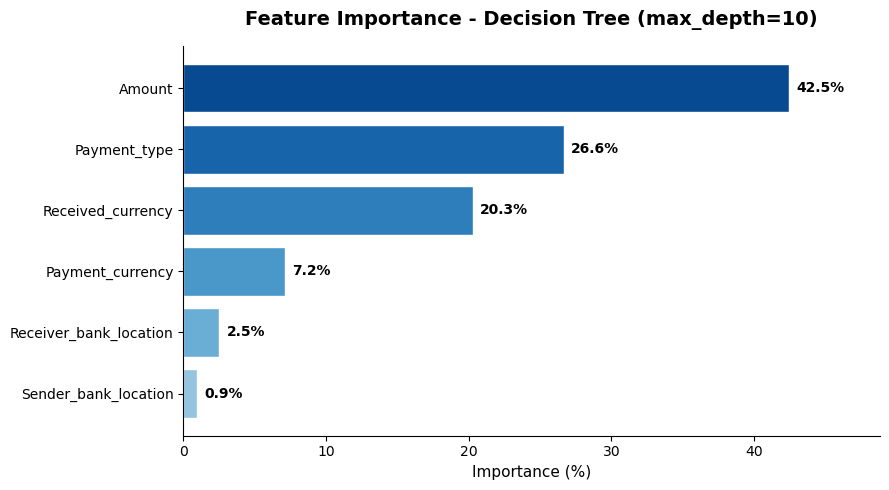

In [25]:
# Feature Importance (bar chart horizontal)
dt_importance_sorted = dt_importance.sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
colors_bar = plt.cm.Blues(np.linspace(0.4, 0.9, len(dt_importance_sorted)))
ax.barh(dt_importance_sorted.index, dt_importance_sorted.values * 100, color=colors_bar, edgecolor="white")
for i, (name, val) in enumerate(dt_importance_sorted.items()):
    ax.text(val * 100 + 0.5, i, f"{val*100:.1f}%",
            va="center", fontsize=10, fontweight="bold")
ax.set_xlabel("Importance (%)", fontsize=11)
ax.set_title("Feature Importance - Decision Tree (max_depth=10)",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlim(0, dt_importance_sorted.max() * 100 * 1.15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


---

## 6. Conclusion & Improvement areas

### Business reading

In an AML context, **it is better to generate false alerts than to let real money laundering slip through** — **recall takes priority over precision**.

Field comparison — share of suspicious activity reports leading to an investigation:

- **EU (Europol, 2017)**: slightly more than 10%
- **France (TRACFIN, 2024)**: slightly less than 2% (215,410 received → 3,998 forwarded)
- **Our model**: 43% recall — significant, but still many false positives

### 4 improvement areas

| # | Area | Technique | Expected impact |
|---|---|---|---|
| 1 | Resampling | **SMOTE** — synthetic minority examples | Recall ↑ |
| 2 | Feature engineering | Temporal & behavioral patterns | Recall & Precision ↑ |
| 3 | Model | **XGBoost** — strong on tabular, imbalanced data | Overall score ↑ |
| 4 | Calibration | Decision threshold tuning | Precision ↑ |

---

*Unified notebook — Jedha Bootcamp Data Essentials final project*